##CLV ANALYSIS ON CONCATENATED SALEWA DATA

After the exploration and analysis of Ecommerce and Retail data, in this part we examined the relationship between the formula we use in CLV calculation and the different models we use for CLV estimation.

First, we add the necessary libraries to the project.

In [1]:
!pip install lifetimes

In [2]:
#Basic Libraries
import pandas as pd
import numpy as np
#Libraries for convertion and calculation of the transactional data
from lifetimes.utils import summary_data_from_transaction_data
from lifetimes import BetaGeoFitter
from lifetimes import GammaGammaFitter #...
#Libraries for different metrics, error and accuracy calculation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split
#Libraries for different models
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import ExtraTreesRegressor
#Libraries for transformation and scaling of the data
from sklearn.preprocessing import StandardScaler, QuantileTransformer
#Libraries for visualization
import seaborn as sns
import matplotlib.pyplot as plt

###Concatenating Ecommerce and Salewa Data

In [3]:
df_ecom = pd.read_parquet("ecom_202412061441.parquet")
df_retail = pd.read_parquet("retail_20250114_2.parquet")

We make sure that we only process Salewa data for retail data and both data have the same type of DATE and TIME format.

In [4]:

df_salewa_retail = df_retail[df_retail["CODEARTICLE"].notnull() & df_retail["CODEARTICLE"].str.startswith("00-")]

# Split ordertime into DATE and TIME for ecom
df_ecom["ordertime"] = pd.to_datetime(df_ecom["ordertime"], errors="coerce")
df_ecom["DATE"] = df_ecom["ordertime"].dt.strftime('%Y-%m-%d')
df_ecom["TIME"] = df_ecom["ordertime"].dt.strftime('%H:%M:%S')

# Ensure DATE and TIME remain unchanged in salewa_retail
df_salewa_retail["DATE"] = pd.to_datetime(df_salewa_retail["DATE"], errors="coerce").dt.strftime('%Y-%m-%d')


We specify the columns that we are interested in and we prepare them for concatenation.

In [5]:
# Align columns for concatenation
df_salewa_retail = df_salewa_retail.assign(
    CUSTOMERID=df_salewa_retail["CBRID"].astype(str),
    CODEOFARTICLE=df_salewa_retail["CODEARTICLE"],
    EAN=df_salewa_retail["EANCODE"],
    PRICE=df_salewa_retail["TOTALTAXINCLUDED"],
    OBERALPID=df_salewa_retail["OBERALPID"],
    QUANTITY=df_salewa_retail["QUANTITY"],
    CURRENCY=df_salewa_retail["CURRENCYID"]
)

df_ecom = df_ecom.assign(
    CUSTOMERID=df_ecom["customernumber"].astype(str),
    CODEOFARTICLE=df_ecom["articleordernumber"],
    EAN=df_ecom["ean"],
    PRICE=df_ecom["price"],
    OBERALPID=df_ecom["oberalp_id"],
    QUANTITY=df_ecom["quantity"],
    CURRENCY=df_ecom["currency"]
)

# Columns in the desired order
columns_to_keep = ["CUSTOMERID", "DATE", "TIME", "EAN", "CODEOFARTICLE", "QUANTITY", "PRICE", "CURRENCY", "OBERALPID"]
salewa_retail = df_salewa_retail[columns_to_keep]
ecom = df_ecom[columns_to_keep]


We start concatenation process and filtering negative PRICE and QUANTITY values for calculating REVENUE.

In [6]:
# Concatenate the DataFrames
concat_df = pd.concat([salewa_retail, ecom], ignore_index=True)

# Transfer TIME values from df_salewa_retail directly to concat_df
concat_df.loc[:len(df_salewa_retail)-1, "TIME"] = df_salewa_retail["TIME"].values

concat_df = concat_df[(concat_df['PRICE'] > 0) & (concat_df['QUANTITY'] > 0)]

# Ensuring the desired data types for each column in concat_df
concat_df['CUSTOMERID'] = concat_df['CUSTOMERID'].astype(str)
concat_df['DATE'] = pd.to_datetime(concat_df['DATE'], errors='coerce')
concat_df['EAN'] = concat_df['EAN'].astype(str)
concat_df['CODEOFARTICLE'] = concat_df['CODEOFARTICLE'].astype(str)
concat_df['PRICE'] = pd.to_numeric(concat_df['PRICE'], errors='coerce')
concat_df['CURRENCY'] = concat_df['CURRENCY'].astype(str)
concat_df['OBERALPID'] = concat_df['OBERALPID'].astype(str)

concat_df['REVENUE'] = concat_df['PRICE'] * concat_df['QUANTITY']

concat_df

,CUSTOMERID,DATE,TIME,EAN,CODEOFARTICLE,QUANTITY,PRICE,CURRENCY,OBERALPID,REVENUE
0,RAT0100132257,2024-11-30,15:31:30,4053865477766,00-0000025858,1,40.00,EUR,None,40.00
2,RAT0100132257,2024-11-30,15:28:14,4053866573085,00-0000028455,1,311.43,EUR,None,311.43
3,RAT0100132257,2024-11-30,15:28:14,4053866585965,00-0000028774,1,28.81,EUR,None,28.81
4,RAT0100132257,2024-11-30,15:28:14,4053866539968,00-0000028644,1,23.36,EUR,None,23.36
5,RAT0100125170,2024-11-30,14:33:58,4053866143721,00-0000034107,1,7.20,EUR,175e6044-526d-ed11-9561-0022489ba636,7.20
...,...,...,...,...,...,...,...,...,...,...
1707443,21676,2017-11-10,10:15:39,4053865795518,00-0000026137_0000000075,1,90.00,EUR,8d2e6e63-d0bd-e511-80c5-005056967814,90.00
1707444,21677,2017-11-10,10:05:04,9009000075446,00-0000025071_0000000004,1,28.00,EUR,24965e62-f3c5-e711-80d0-00505696552f,28.00
1707445,21391,2017-10-31,14:25:29,4053865613775,00-0000064410_0000000004,1,170.00,EUR,None,170.00
1707446,20925,2017-10-25,21:34:31,4053865613829,00-0000064410_0000000009,1,170.00,EUR,6ce84b36-1bac-e711-80d0-00505696552f,170.00


###Converting Transaction Data to Summary Format

As a result of the different combinations we tried, we used the data of 2023 and 2024 in our calculations. In order to have a more equal calculation, we fixed the 2023 data to November 30, which is the last date of the 2024 data.

In [7]:
# Preparation of the data for different years.
df_2023 = concat_df[(concat_df["DATE"] >= "2023-01-01") & (concat_df["DATE"] <= "2023-11-30")]
df_2024 = concat_df[(concat_df["DATE"] >= "2024-01-01") & (concat_df["DATE"] <= "2024-11-30")]

# Prepare summary data for 2023.
summary_2023 = summary_data_from_transaction_data(
    df_2023,
    customer_id_col='CUSTOMERID',
    datetime_col='DATE',
    monetary_value_col='REVENUE',
    observation_period_end='2023-11-30'
)
# Filter negative and 0 values.
summary_2023 = summary_2023[(summary_2023["recency"] > 0) &
                             (summary_2023["frequency"] > 0) &
                             (summary_2023["T"] > 0) &
                             (summary_2023["monetary_value"] > 0)]


summary_2023.head()

,frequency,recency,T,monetary_value
CUSTOMERID,,,,
100072,2.0,141.0,145.0,580.0
100097,2.0,105.0,200.0,143.5
100128,1.0,86.0,175.0,501.0
100285,4.0,173.0,271.0,327.0
100316,1.0,146.0,205.0,70.0


In [8]:
# Calculate predicted purchases by using BetaGeoFitter
bgf = BetaGeoFitter()
bgf.fit(summary_2023['frequency'], summary_2023['recency'], summary_2023['T'])

summary_2023["predicted_purchases_2024"] = bgf.conditional_expected_number_of_purchases_up_to_time(
    365, summary_2023['frequency'], summary_2023['recency'], summary_2023['T']
)

summary_2023 = summary_2023.reset_index()
summary_2023.head()

,CUSTOMERID,frequency,recency,T,monetary_value,predicted_purchases_2024
0,100072,2.0,141.0,145.0,580.0,1.777624
1,100097,2.0,105.0,200.0,143.5,0.730282
2,100128,1.0,86.0,175.0,501.0,0.414764
3,100285,4.0,173.0,271.0,327.0,1.294326
4,100316,1.0,146.0,205.0,70.0,0.594117


In [9]:
# Same operations for 2024 data.
summary_2024 = summary_data_from_transaction_data(
    df_2024,
    customer_id_col='CUSTOMERID',
    datetime_col='DATE',
    monetary_value_col='REVENUE',
    observation_period_end='2024-11-30'
)

In [10]:
summary_2024 = summary_2024[(summary_2024["recency"] > 0) &
                             (summary_2024["frequency"] > 0) &
                             (summary_2024["T"] > 0) &
                             (summary_2024["monetary_value"] > 0)]

summary_2024 = summary_2024.reset_index()
summary_2024.head()

,CUSTOMERID,frequency,recency,T,monetary_value
0,100097,1.0,47.0,213.0,250.0
1,100117,2.0,87.0,236.0,60.0
2,100193,2.0,219.0,321.0,217.5
3,100285,2.0,161.0,223.0,430.0
4,100668,2.0,56.0,202.0,269.0


We rename so that the column names of two different year data do not conflict.

In [11]:
# Rename column names
summary_2023 = summary_2023.rename(columns={
    "frequency": "frequency_2023",
    "recency": "recency_2023",
    "T": "T_2023",
    "monetary_value": "monetary_value_2023"
})

summary_2024 = summary_2024.rename(columns={
    "frequency": "frequency_2024",
    "recency": "recency_2024",
    "T": "T_2024",
    "monetary_value": "monetary_value_2024"
})

Calculate actual CLV by using formula for 2024.

ACTUAL CLV = MONETARY VALUE * (FREQUENCY / FREQUENCY + 1)

In [12]:
summary_2024["actual_clv_2024"] = (
    summary_2024["monetary_value_2024"] * summary_2024["frequency_2024"]
) / (summary_2024["frequency_2024"] + 1)

# Merge 2023 and 2024 data
merged_clv = summary_2023.merge(
    summary_2024[["CUSTOMERID", "actual_clv_2024", "frequency_2024", "recency_2024", "T_2024", "monetary_value_2024"]],
    on="CUSTOMERID",
    how="inner"  # Only customers in both 2023 and 2024
)

merged_clv.head()

,CUSTOMERID,frequency_2023,recency_2023,T_2023,monetary_value_2023,predicted_purchases_2024,actual_clv_2024,frequency_2024,recency_2024,T_2024,monetary_value_2024
0,100097,2.0,105.0,200.0,143.5,0.730282,125.000000,1.0,47.0,213.0,250.0
1,100285,4.0,173.0,271.0,327.0,1.294326,286.666667,2.0,161.0,223.0,430.0
2,100668,2.0,174.0,250.0,245.0,0.936638,179.333333,2.0,56.0,202.0,269.0
3,101101,2.0,186.0,312.0,640.0,0.584396,65.000000,1.0,80.0,291.0,130.0
4,101132,5.0,314.0,324.0,166.0,2.941197,65.000000,1.0,104.0,332.0,130.0


##CLV Estimation Using Different Models

We aim to predict CLV by testing different models and find results that are closest to the actual CLV we calculated. 2023 data will be used to predict CLV for 2024.

Firstly, we create additional variables that can be used for CLV prediction. Then we add those variables to our data.

In [13]:
def feature_engineering(df):
    df = df.copy()
    df["customer_lifespan"] = df["T_2023"] - df["recency_2023"]
    df["avg_time_between_purchases"] = df["T_2023"] / (df["frequency_2023"] + 1)
    df["monetary_per_purchase"] = df["monetary_value_2023"] / (df["frequency_2023"] + 1)
    df["purchase_frequency_ratio"] = df["frequency_2023"] / (df["T_2023"] + 1)
    df["monetary_per_time"] = df["monetary_value_2023"] / (df["T_2023"] + 1)
    df["purchase_velocity"] = df["frequency_2023"] / (df["customer_lifespan"] + 1)
    df["scaled_recency"] = df["recency_2023"] / (df["T_2023"] + 1)
    df["log_monetary_value"] = np.log1p(df["monetary_value_2023"])
    df["log_monetary_per_time"] = df["log_monetary_value"] / (df["T_2023"] + 1)
    return df


merged_clv = feature_engineering(merged_clv)

Scaling and log transformation ensure that the model can effectively learn from different variables and generalize better to unseen data.

In [14]:
scaler = StandardScaler()
log_transformer = QuantileTransformer(output_distribution='normal')

features = merged_clv.select_dtypes(include=[np.number]).columns.tolist()
features.remove("actual_clv_2024")

X = merged_clv[features]
y = merged_clv["actual_clv_2024"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
y_train = log_transformer.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test = log_transformer.transform(y_test.values.reshape(-1, 1)).ravel()


Predicting CLV is a challenging task, requiring powerful models that can capture customer behavior patterns. In this study, we utilize three different machine learning models: XGBoost (XGB), Extra Trees Regressor (ETR), and Multi-Layer Perceptron (MLP). Each model brings a unique approach to improving CLV prediction accuracy.

**XGBoost** is an ensemble learning algorithm based on decision trees, using gradient boosting to improve performance.
- Handles complex, non-linear relationships in customer data.
- Feature importance ranking helps identify the key drivers of CLV.
- Performs well on structured data, making it a strong baseline model.

In [15]:

xgb = XGBRegressor(
    n_estimators=700,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.5,
    reg_lambda=0.5,
    gamma=0.1,
    random_state=42
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
y_train_pred_xgb = xgb.predict(X_train)

**Extra Trees Regressor** is a tree-based ensemble model similar to Random Forest but with more randomization.
- Reduces overfitting by adding more randomness in tree splits.
- Handles noisy and unbalanced data efficiently.
- Performs well with a large number of features, capturing subtle patterns in customer transactions.


In [16]:
#Extra Trees Regressor Model
etr = ExtraTreesRegressor(
    n_estimators=5000,
    max_depth=None,
    min_samples_split=6,
    min_samples_leaf=5,
    max_features=0.8,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)
etr.fit(X_train, y_train)
y_pred_etr = etr.predict(X_test)
y_train_pred_etr = etr.predict(X_train)

**MLP** is a deep learning model that captures complex patterns by learning from past customer interactions.
- Captures deep, hidden patterns that tree-based models might miss.
- Adapts well to sequential and complex data distributions.
- Useful when CLV prediction involves non-linear customer behaviors.

In [17]:
mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32, 16),
    activation='relu',
    solver='adam',
    alpha=0.05,
    learning_rate='adaptive',
    max_iter=700,
    early_stopping=True,
    batch_size=64,
    random_state=42
)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)
y_train_pred_mlp = mlp.predict(X_train)

Calculate metrics

In [18]:
# Compare models by different metrics
def calculate_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

In [19]:

metrics_xgb = calculate_metrics(y_test, y_pred_xgb)
metrics_etr = calculate_metrics(y_test, y_pred_etr)
metrics_mlp = calculate_metrics(y_test, y_pred_mlp)


train_metrics_xgb = calculate_metrics(y_train, y_train_pred_xgb)
train_metrics_etr = calculate_metrics(y_train, y_train_pred_etr)
train_metrics_mlp = calculate_metrics(y_train, y_train_pred_mlp)


print("\n CLV Model Performance Comparison (Test Set) \n")
print(f" XGBoost {metrics_xgb}")
print(f" Extra Trees Regressor {metrics_etr}")
print(f" MLPRegressor (Neural Network - Sklearn) {metrics_mlp}")


 CLV Model Performance Comparison (Test Set) 

 XGBoost {'MAE': 0.029565751303147394, 'RMSE': 0.04825162263335178, 'R2': 0.997698755894913}
 Extra Trees Regressor {'MAE': 0.07541117531896653, 'RMSE': 0.1318725272167586, 'R2': 0.9828111230739528}
 MLPRegressor (Neural Network - Sklearn) {'MAE': 0.04665002040821227, 'RMSE': 0.07369196668045848, 'R2': 0.99463241243763}


Choose the best model and make CLV prediction

In [20]:

best_model = max([(xgb, metrics_xgb), (etr, metrics_etr), (mlp, metrics_mlp)], key=lambda x: x[1]['R2'])[0]
y_pred_all = best_model.predict(scaler.transform(X))
y_pred_all_original = log_transformer.inverse_transform(y_pred_all.reshape(-1, 1)).flatten()

merged_clv["predicted_clv_2024"] = np.round(y_pred_all_original, 2)

Select top 10 customers according to actual clv and display predicted clv with it.

In [21]:
top_10_customers_2024 = (
    merged_clv.sort_values(by="actual_clv_2024", ascending=False)
    .drop_duplicates(subset="CUSTOMERID", keep="first")  # Include customers only once
    .head(10)
)

#Add CURRENCY to final table
top_10_customers_2024 = top_10_customers_2024.merge(
    concat_df[["CUSTOMERID", "CURRENCY"]].drop_duplicates(subset="CUSTOMERID"),
    on="CUSTOMERID",
    how="left"
)

#Only select specific columns
top_10_customers_2024 = top_10_customers_2024[["CUSTOMERID", "actual_clv_2024", "predicted_clv_2024", "CURRENCY"]]
top_10_customers_2024[["actual_clv_2024", "predicted_clv_2024"]] = top_10_customers_2024[["actual_clv_2024", "predicted_clv_2024"]].round(2)

#Display the result in 2 decimal points
pd.options.display.float_format = '{:.2f}'.format

print("\n Customers with Top 10 CLV  (2024) \n")

top_10_customers_2024


 Customers with Top 10 CLV  (2024) 



,CUSTOMERID,actual_clv_2024,predicted_clv_2024,CURRENCY
0,RIT2700004951,4317.75,4300.55,EUR
1,127150,2040.00,877.24,EUR
2,149670,1783.50,1373.84,EUR
3,155058,1538.33,1260.40,EUR
4,148733,1463.86,1222.10,EUR
5,56148,1400.71,1207.99,EUR
6,197670,1271.20,1017.96,EUR
7,147581,1113.33,750.93,EUR
8,181775,1096.00,1423.27,EUR
9,69997,997.67,1168.56,EUR


Calculate the accuracy

In [22]:
mape = mean_absolute_percentage_error(merged_clv["actual_clv_2024"], merged_clv["predicted_clv_2024"]) * 100

r2 = r2_score(merged_clv["actual_clv_2024"], merged_clv["predicted_clv_2024"])

print(f" Accuracy Metrics for Actual vs. Predicted CLV 2024")
print(f"🔹 MAPE: {mape:.2f}%")
print(f"🔹 R² Score: {r2:.4f}")

 Accuracy Metrics for Actual vs. Predicted CLV 2024
🔹 MAPE: 2.14%
🔹 R² Score: 0.9658


###Future Prediction for 2025

After making our calculations for 2024, we wanted to make a future prediction for 2025. We will use 2023 and 2024 data together for the 2025 forecast. For prediction, we will use the average of the summary data of 2023 and 2024. The calculation only includes customers who have made purchases in both years.

In [23]:
features_2025 = merged_clv.copy()

# It is used for preventing division problems
features_2025["frequency_2024"].fillna(0, inplace=True)
features_2025["recency_2024"].fillna(features_2025["recency_2023"], inplace=True)
features_2025["T_2024"].fillna(features_2025["T_2023"], inplace=True)
features_2025["monetary_value_2024"].fillna(features_2025["monetary_value_2023"], inplace=True)

# Calculate the average for each variables
features_2025["frequency_2025"] = (features_2025["frequency_2023"] + features_2025["frequency_2024"]) / 2
features_2025["recency_2025"] = (features_2025["recency_2023"] + features_2025["recency_2024"]) / 2
features_2025["T_2025"] = (features_2025["T_2023"] + features_2025["T_2024"]) / 2
features_2025["monetary_value_2025"] = (features_2025["monetary_value_2023"] + features_2025["monetary_value_2024"]) / 2

# Apply the formula
features_2025["predicted_clv_2025_formula"] = (features_2025["monetary_value_2025"] * features_2025["frequency_2025"]) / (features_2025["frequency_2025"] + 1)

In [24]:
features_2025["predicted_clv_2025_formula"].fillna(0, inplace=True)

# Specify the columns
features_2025 = features_2025[["CUSTOMERID", "predicted_clv_2025_formula"]].round(2)

In [25]:
# Print top 10 customers with highest CLV estimated for 2025
top_10_customers_2025_formula = features_2025.sort_values(by="predicted_clv_2025_formula", ascending=False).head(10)


top_10_customers_2025_formula = top_10_customers_2025_formula.merge(
    concat_df[["CUSTOMERID", "CURRENCY"]].drop_duplicates(subset="CUSTOMERID"),
    on="CUSTOMERID",
    how="left"
)


print("\n Top 10 Customers with Highest CLV Estimated for 2025 - Formula \n")
top_10_customers_2025_formula


 Top 10 Customers with Highest CLV Estimated for 2025 - Formula 



,CUSTOMERID,predicted_clv_2025_formula,CURRENCY
0,81903,3922.57,CHF
1,RIT2700004951,2859.12,EUR
2,58671,1626.87,CHF
3,59165,1624.67,EUR
4,155058,1460.42,EUR
5,150242,1388.86,EUR
6,127150,1378.50,EUR
7,149670,1216.75,EUR
8,178176,1015.47,EUR
9,182479,1002.05,EUR


###CLV Estimation for 2025 Using Different Models

We also make our CLV prediction for 2025 with models.

In [26]:
# Feature Engineering
def feature_engineering(df):
    df = df.copy()

    # Time based metrics
    df["customer_lifespan"] = df["T_2023"] - df["recency_2023"]
    df["avg_time_between_purchases_2023"] = df["T_2023"] / (df["frequency_2023"] + 1)
    df["avg_time_between_purchases_2024"] = df["T_2024"] / (df["frequency_2024"] + 1)

    # Monetary metrics
    df["monetary_per_purchase_2023"] = df["monetary_value_2023"] / (df["frequency_2023"] + 1)
    df["monetary_per_purchase_2024"] = df["monetary_value_2024"] / (df["frequency_2024"] + 1)

    # Frequency based metrics
    df["purchase_frequency_ratio_2023"] = df["frequency_2023"] / (df["T_2023"] + 1)
    df["purchase_frequency_ratio_2024"] = df["frequency_2024"] / (df["T_2024"] + 1)

    # Log transformation
    df["log_monetary_value_2023"] = np.log1p(df["monetary_value_2023"])
    df["log_monetary_value_2024"] = np.log1p(df["monetary_value_2024"])

    return df

In [27]:
# Apply feature engineering and scaling
merged_clv = feature_engineering(merged_clv)
merged_clv = merged_clv.dropna()

scaler = StandardScaler()

In [28]:
# We use both 2023 and 2024 features
features = [
    "frequency_2023", "recency_2023", "T_2023", "monetary_value_2023",
    "frequency_2024", "recency_2024", "T_2024", "monetary_value_2024",
    "avg_time_between_purchases_2023", "avg_time_between_purchases_2024",
    "monetary_per_purchase_2023", "monetary_per_purchase_2024",
    "purchase_frequency_ratio_2023", "purchase_frequency_ratio_2024",
    "log_monetary_value_2023", "log_monetary_value_2024"
]

#Train test splitting
X = merged_clv[features]
y = np.log1p(features_2025["predicted_clv_2025_formula"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

We are using the models we mentioned before again.

In [29]:
# XGBoost Model
xgb = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.02,
    max_depth=8,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.2,
    reg_lambda=0.5,
    gamma=0.05,
    random_state=42
)
xgb.fit(X_train, y_train)
y_pred_xgb = np.expm1(xgb.predict(X_test))

In [30]:
# Extra Trees Regressor Model
etr = ExtraTreesRegressor(
    n_estimators=7000,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=4,
    max_features=0.9,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)
etr.fit(X_train, y_train)
y_pred_etr = np.expm1(etr.predict(X_test))

Now we calculate the metrics and print the results.

In [31]:
# Compare model performances
def calculate_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

metrics_xgb = calculate_metrics(np.expm1(y_test), y_pred_xgb)
metrics_etr = calculate_metrics(np.expm1(y_test), y_pred_etr)

print("\n CLV Model Performance Comparison \n")
print(f"🔹 XGBoost {metrics_xgb}")


 CLV Model Performance Comparison 

🔹 XGBoost {'MAE': 6.756654103048127, 'RMSE': 39.404656729324415, 'R2': 0.8700328091187473}


XGB performs better than ETR, therefore we use XGB for predictions by using our pre-defined features

In [32]:
features_2025 = merged_clv.copy()

X_2025 = features_2025[features]
X_2025_scaled = scaler.transform(X_2025)

best_model = xgb
y_pred_2025 = np.expm1(best_model.predict(X_2025_scaled))

# Add predictions to the dataframe
features_2025["predicted_clv_2025_model"] = np.round(y_pred_2025, 2)

In [33]:
# Select top 10 customers with highest CLV estimated for 2025 by using XGB. Also compare performances
top_10_customers_2025_model = (
    features_2025.sort_values(by="predicted_clv_2025_model", ascending=False)
    .drop_duplicates(subset="CUSTOMERID", keep="first")
    .head(10)
)


top_10_customers_2025_model = top_10_customers_2025_model.merge(
    concat_df[["CUSTOMERID", "CURRENCY"]].drop_duplicates(subset="CUSTOMERID"),
    on="CUSTOMERID",
    how="left"
)


top_10_customers_2025_model = top_10_customers_2025_model[["CUSTOMERID", "predicted_clv_2025_model", "CURRENCY"]]

top_10_customers_2025_model["predicted_clv_2025_model"] = top_10_customers_2025_model["predicted_clv_2025_model"].astype(float).round(2)

pd.options.display.float_format = '{:.2f}'.format


top_10_customers_2025_model

,CUSTOMERID,predicted_clv_2025_model,CURRENCY
0,81903,2719.47,CHF
1,RIT2700004951,2687.94,EUR
2,59165,1552.15,EUR
3,155058,1404.31,EUR
4,58671,1297.80,CHF
5,149670,1119.37,EUR
6,126592,1070.06,EUR
7,182479,990.16,EUR
8,90587,975.13,EUR
9,169758,968.11,EUR


###Visualization of Results

We interpret the results we obtain with different visualizations.

First of all, we compare the calculations we made for 2024 with the predictions of the model.

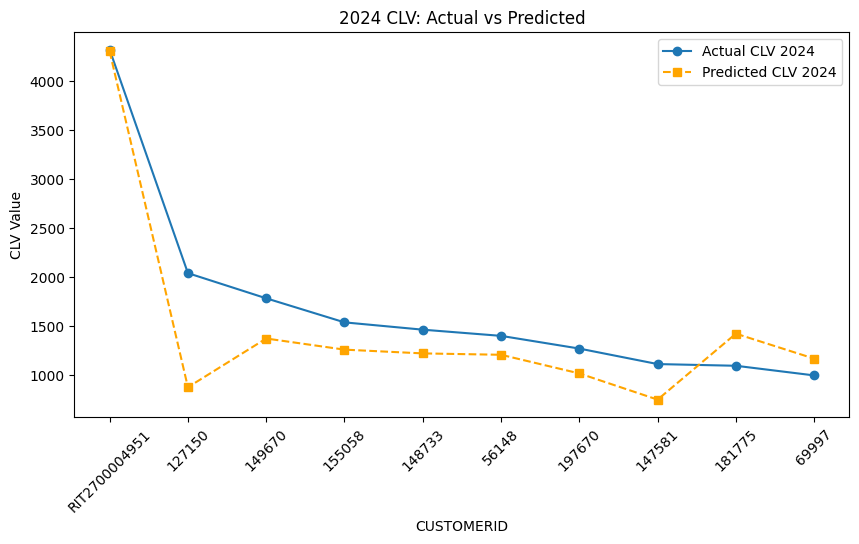

In [34]:
# 2024 Line Graph (Actual vs. Predicted CLV)
plt.figure(figsize=(10, 5))
plt.plot(top_10_customers_2024["CUSTOMERID"].astype(str), top_10_customers_2024["actual_clv_2024"], marker='o', linestyle='-', label="Actual CLV 2024")
plt.plot(top_10_customers_2024["CUSTOMERID"].astype(str), top_10_customers_2024["predicted_clv_2024"], marker='s', linestyle='--', label="Predicted CLV 2024", color="orange")

plt.xlabel("CUSTOMERID")
plt.ylabel("CLV Value")
plt.title("2024 CLV: Actual vs Predicted")
plt.xticks(rotation=45)
plt.legend()
plt.show()

The graph shows that the model has difficulty predicting values ​​that are well above the average, which we can accept as standard deviation, but it can very closely and successfully predict CLV values ​​that are close to the average.

We made two different predictions for 2025, using a formula and using a model. We compare these results in another graph.

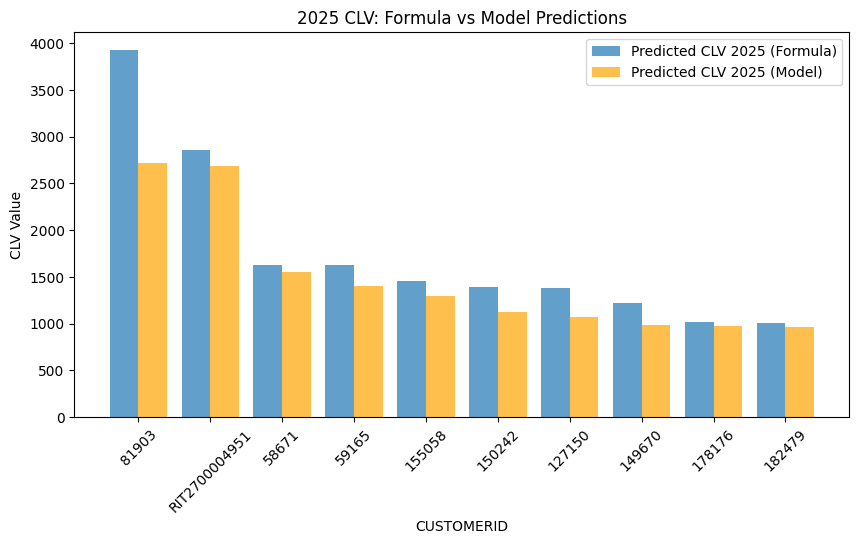

In [35]:
plt.figure(figsize=(10, 5))
bar_width = 0.4
x_labels = top_10_customers_2025_formula["CUSTOMERID"].astype(str)
x_indexes = np.arange(len(x_labels))

plt.bar(x_indexes - bar_width/2, top_10_customers_2025_formula["predicted_clv_2025_formula"],
        width=bar_width, label="Predicted CLV 2025 (Formula)", alpha=0.7)
plt.bar(x_indexes + bar_width/2, top_10_customers_2025_model["predicted_clv_2025_model"],
        width=bar_width, label="Predicted CLV 2025 (Model)", alpha=0.7, color="orange")

plt.xlabel("CUSTOMERID")
plt.ylabel("CLV Value")
plt.title("2025 CLV: Formula vs Model Predictions")
plt.xticks(ticks=x_indexes, labels=x_labels, rotation=45)
plt.legend()
plt.show()


While the prediction accuracy of the model for 2024 is 96.58%, the prediction accuracy of the model for 2025 is 87%.
- Customers with ID numbers 81903, 58671, 59165, 150242, 178176, 182479 are in 2025 list but not in 2024 list.
- As the date range of the data increases, accuracy decreases and the place of some customers in the ranking changes.

Finally, we visualize the distributions of all the results we obtained.

<ipython-input-36-94e7483a2598>:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([top_10_customers_2024["actual_clv_2024"], top_10_customers_2024["predicted_clv_2024"],


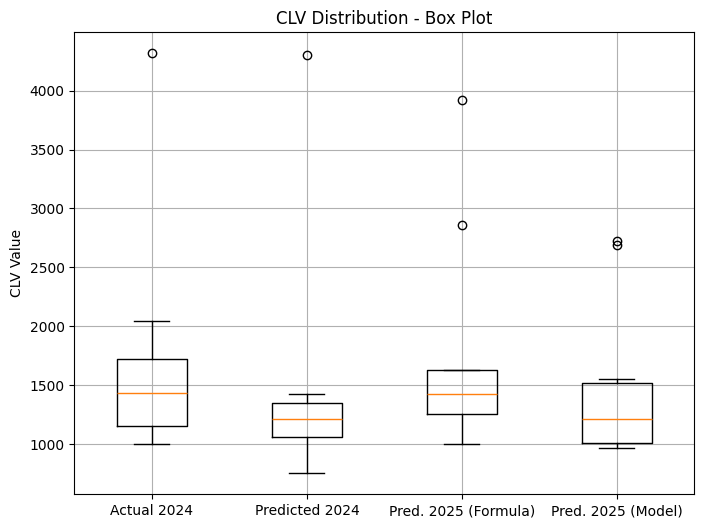

In [36]:
plt.figure(figsize=(8, 6))
plt.boxplot([top_10_customers_2024["actual_clv_2024"], top_10_customers_2024["predicted_clv_2024"],
             top_10_customers_2025_formula["predicted_clv_2025_formula"], top_10_customers_2025_model["predicted_clv_2025_model"]],
            labels=["Actual 2024", "Predicted 2024", "Pred. 2025 (Formula)", "Pred. 2025 (Model)"])
plt.title("CLV Distribution - Box Plot")
plt.ylabel("CLV Value")
plt.grid(True)
plt.show()

- Actual 2024 CLV has the highest median but also exhibits more variability, with some extreme outliers.
- Predicted 2024 CLV is more stable, with a slightly lower median and a narrower spread.
- Formula-based 2025 predictions are slightly higher than the model-based ones, suggesting a different growth assumption.
- Outliers are present across all estimates, indicating a few high-value customers with significantly higher CLV.

As a conclusion, the model appears to provide stable CLV predictions, closely following actual values while reducing variance. However, the 2025 projections show differences between formula-based and model-based estimates, which can be analyzed further.

###Monthly Cohort Analysis

We will examine in detail the purchases of top 10 customers of 2024 with the highest CLV. Both 2023 and 2024 will be included. As a result of these reviews, we will interpret the purchasing behavior of each customer.

In [37]:
# Get YEAR and MONTH data from DATE
concat_df["YEAR"] = concat_df["DATE"].dt.year
concat_df["MONTH"] = concat_df["DATE"].dt.month

# Calculate total REVENUE for each CUSTOMER, MONTH and YEAR
monthly_revenue = concat_df.groupby(["CUSTOMERID", "YEAR", "MONTH"])["REVENUE"].sum().reset_index()

In [38]:
#Create separate cohort tables for 2023 and 2024

cohort_2023 = monthly_revenue[monthly_revenue["YEAR"] == 2023].pivot(index="CUSTOMERID", columns="MONTH", values="REVENUE").fillna(0)

cohort_2024 = monthly_revenue[monthly_revenue["YEAR"] == 2024].pivot(index="CUSTOMERID", columns="MONTH", values="REVENUE").fillna(0)

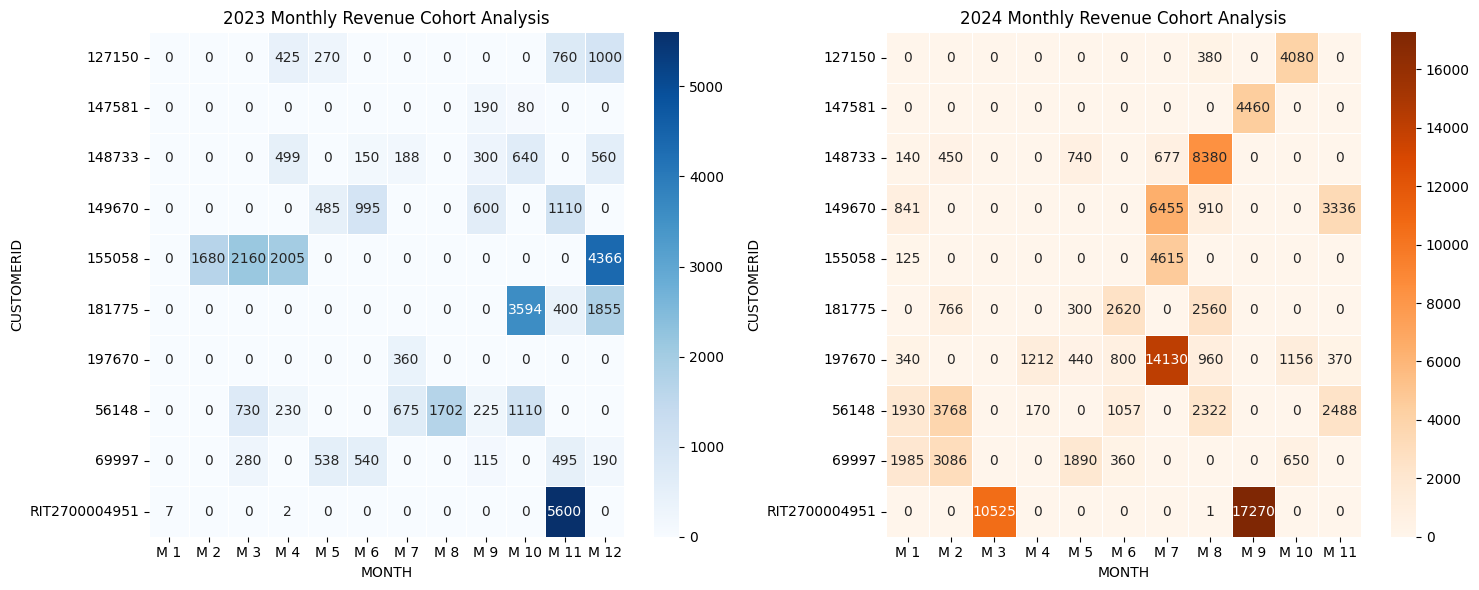

In [39]:
# Select top 10 customers for 2024 for each years.
top_customers = top_10_customers_2024["CUSTOMERID"].unique()
cohort_2023 = cohort_2023.loc[cohort_2023.index.isin(top_customers)]
cohort_2024 = cohort_2024.loc[cohort_2024.index.isin(top_customers)]

# Heatmaps

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 2023 Heatmap
sns.heatmap(cohort_2023, cmap="Blues", annot=True, fmt=".0f", linewidths=0.5, ax=axes[0])
axes[0].set_xticklabels([f"M {i+1}" for i in range(12)])
axes[0].set_yticklabels(cohort_2023.index)
axes[0].set_title("2023 Monthly Revenue Cohort Analysis")

# 2024 Heatmap
sns.heatmap(cohort_2024, cmap="Oranges", annot=True, fmt=".0f", linewidths=0.5, ax=axes[1])
axes[1].set_xticklabels([f"M {i+1}" for i in range(11)])
axes[1].set_yticklabels(cohort_2024.index)
axes[1].set_title("2024 Monthly Revenue Cohort Analysis")

plt.tight_layout()
plt.show()

- 17250: Generally making purchases in the last quarter of years.
- 147581: Generally making purchases at the beginning of the last quarter of years.
- 148733: Makes purchases in different periods of the year, mainly in the second half of years.
- 149670: Prefers to make purchases in summer and winter seasons.
- 181775: Makes regular purchases consecutively in certain months.
- 197670: One of the most purchasing customers of 2024. Made a purchase in 8 out of 11 months.
- 56148: Makes regular purchases over the years, at 1-2 month intervals.
- 69997: Makes regular purchases over the years, at 1-2 month intervals.
- RIT2700004951: Makes infrequent purchases throughout years but at high prices.

###How active are customers with OBERALPID?

We want to determine how many of the customers active in 2023 and 2024 have an OBERALP ID.

In [40]:
summary_2024 = summary_2024.merge(
    concat_df[["CUSTOMERID", "OBERALPID"]].drop_duplicates(subset="CUSTOMERID"),
    on="CUSTOMERID",
    how="left"
)

# Determine which customers also have OBERALPID
summary_2024["has_oberalpid"] = summary_2024["OBERALPID"].notna() & (summary_2024["OBERALPID"] != "") & (summary_2024["OBERALPID"] != "None")

# Calculate the percentage
total_customers = len(summary_2024)
num_with_oberalpid = summary_2024["has_oberalpid"].sum()
percentage_with_oberalpid = (num_with_oberalpid / total_customers) * 100

print(f"🔹 From total {total_customers} customers {num_with_oberalpid} of them have OBERALPID")
print(f"🔹 Therefore percentage compared to all customers is: {percentage_with_oberalpid:.2f}%")


🔹 From total 19895 customers 19652 of them have OBERALPID
🔹 Therefore percentage compared to all customers is: 98.78%


We see that a very large proportion of customers who have been active for 2 years also have OBERALPID.